# $\nu_{\tau}$ Investigation in the Dune Collaboration for Advanced Particle Physics Laboratory 2026 - NN Training
Author: Grzegorz Jędrzejowski \
Supervision: prof. Katarzyna Grzelak


# Includes

In [1]:
import os, sys, importlib
my_home = '/scratch1/gjedrzej/Lab'
os.chdir(my_home) #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

In [2]:
requirements_path = os.path.join(my_home, 'requirements.txt')

%pip install --upgrade pip #Pip 21.3+ is required
%pip install -r {requirements_path}

#you might need to restart the kernel after installing requirements

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
import comet_ml
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

## Seeds for prototyping

In [5]:
np.random.seed(42)
tf.random.set_seed(42)
#there is also one in pd in ml.get_train_val_subsets in shuffle

In [6]:
import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

import analysis.scripts.ml_functions as ml
importlib.reload(ml)

import analysis.scripts.system_functions as sf
importlib.reload(sf)


output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


# File Paths

In [7]:
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')

# Plotting Class Separation Hypothesis before data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

In [8]:
df_all = pd.read_csv(output_path_all)
df_legacy=df_all
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

# pf.plot_tau_energy(df_all, ALL=True) confirmed no taons in the dataset

dfs_preprocessed = [df_all, df_all_CC, df_all_NC]

--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---


--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0, 2000000101.0} ---


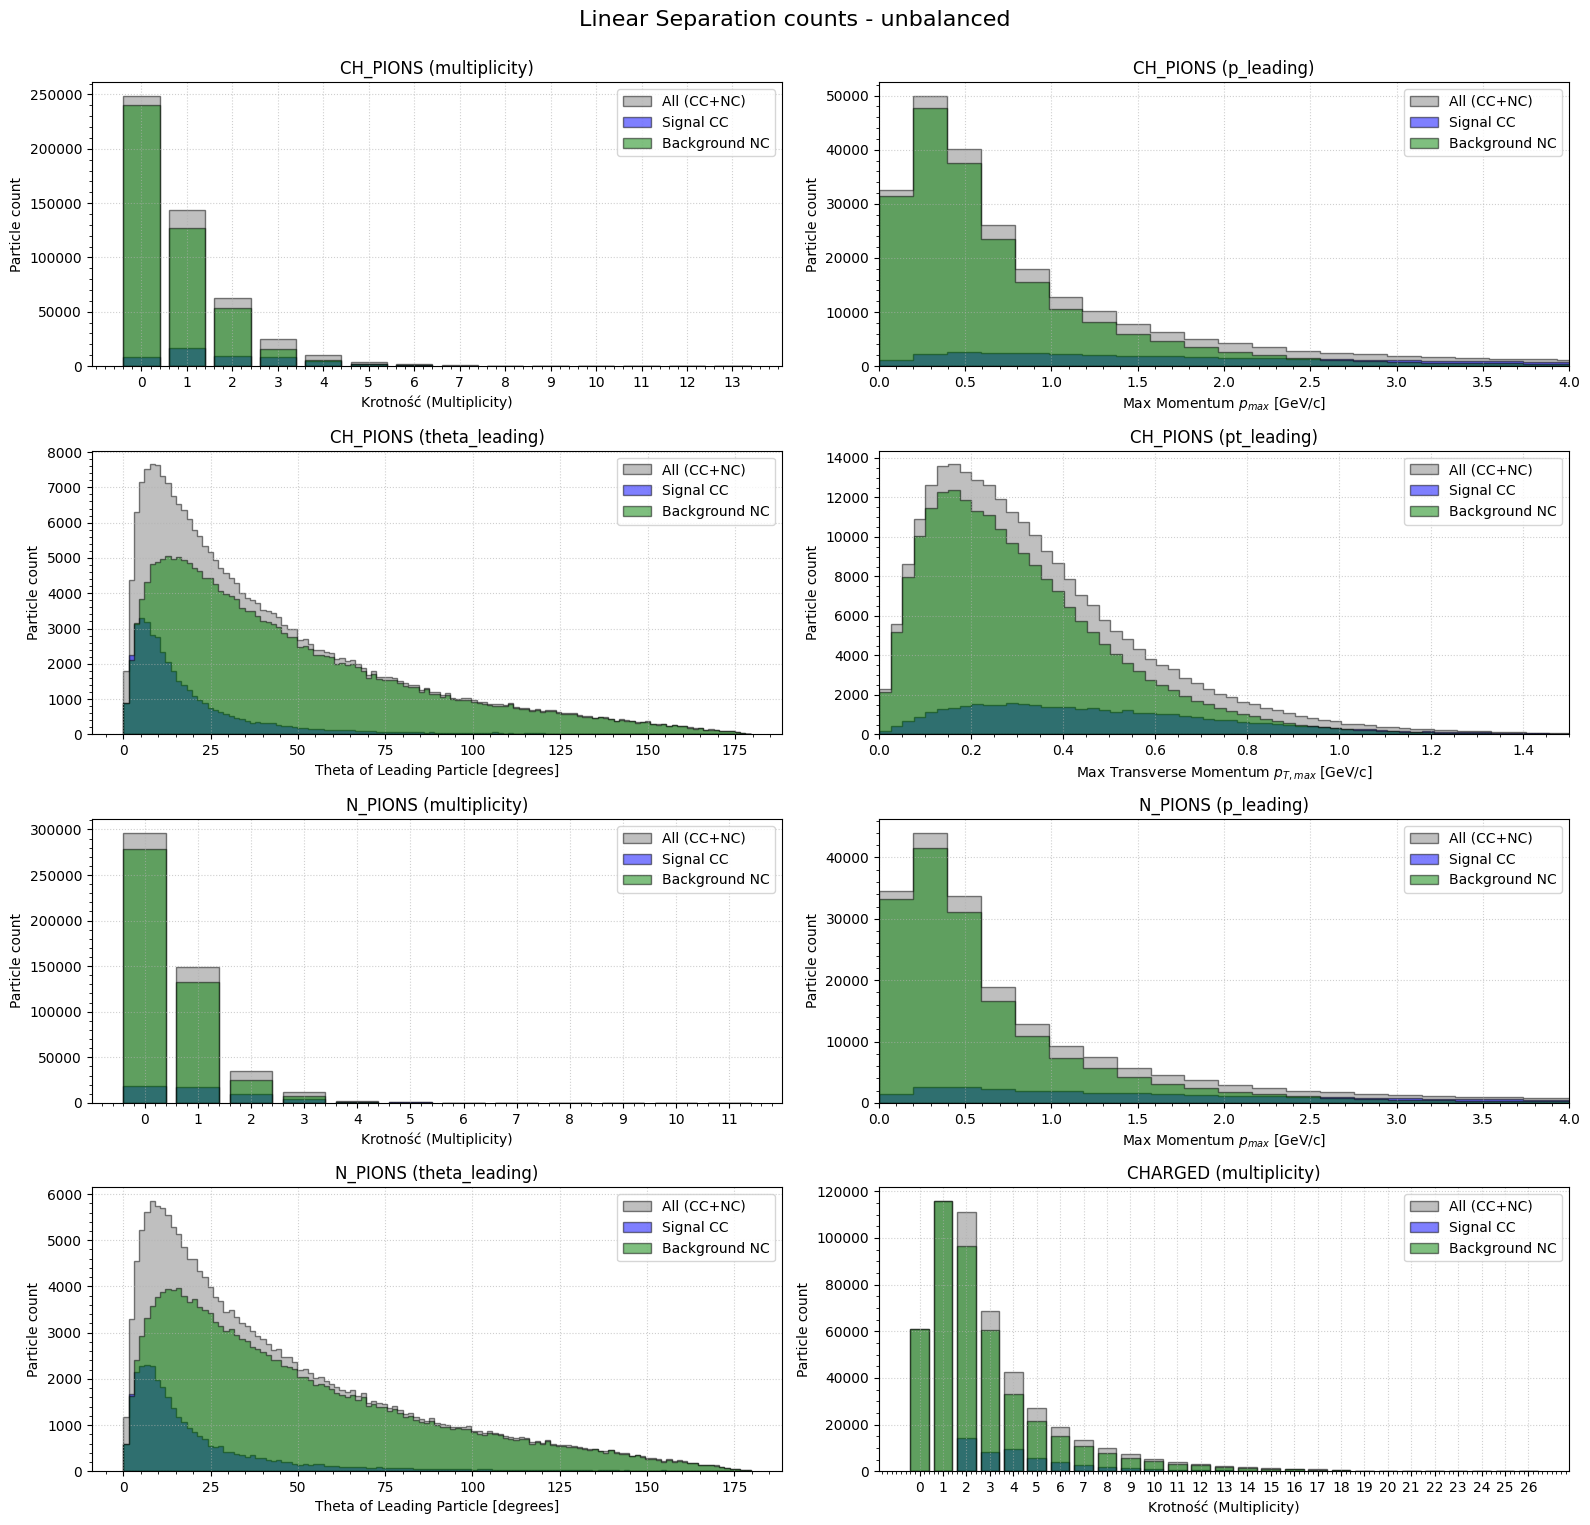

In [142]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=False)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=False)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=False)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='multiplicity', ax=axes[3, 1], density=False)
# axes[3, 1].set_xlim(0, 1.5) 

plt.suptitle("Linear Separation counts - unbalanced", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {1000180400.0, 2000000101.0} ---


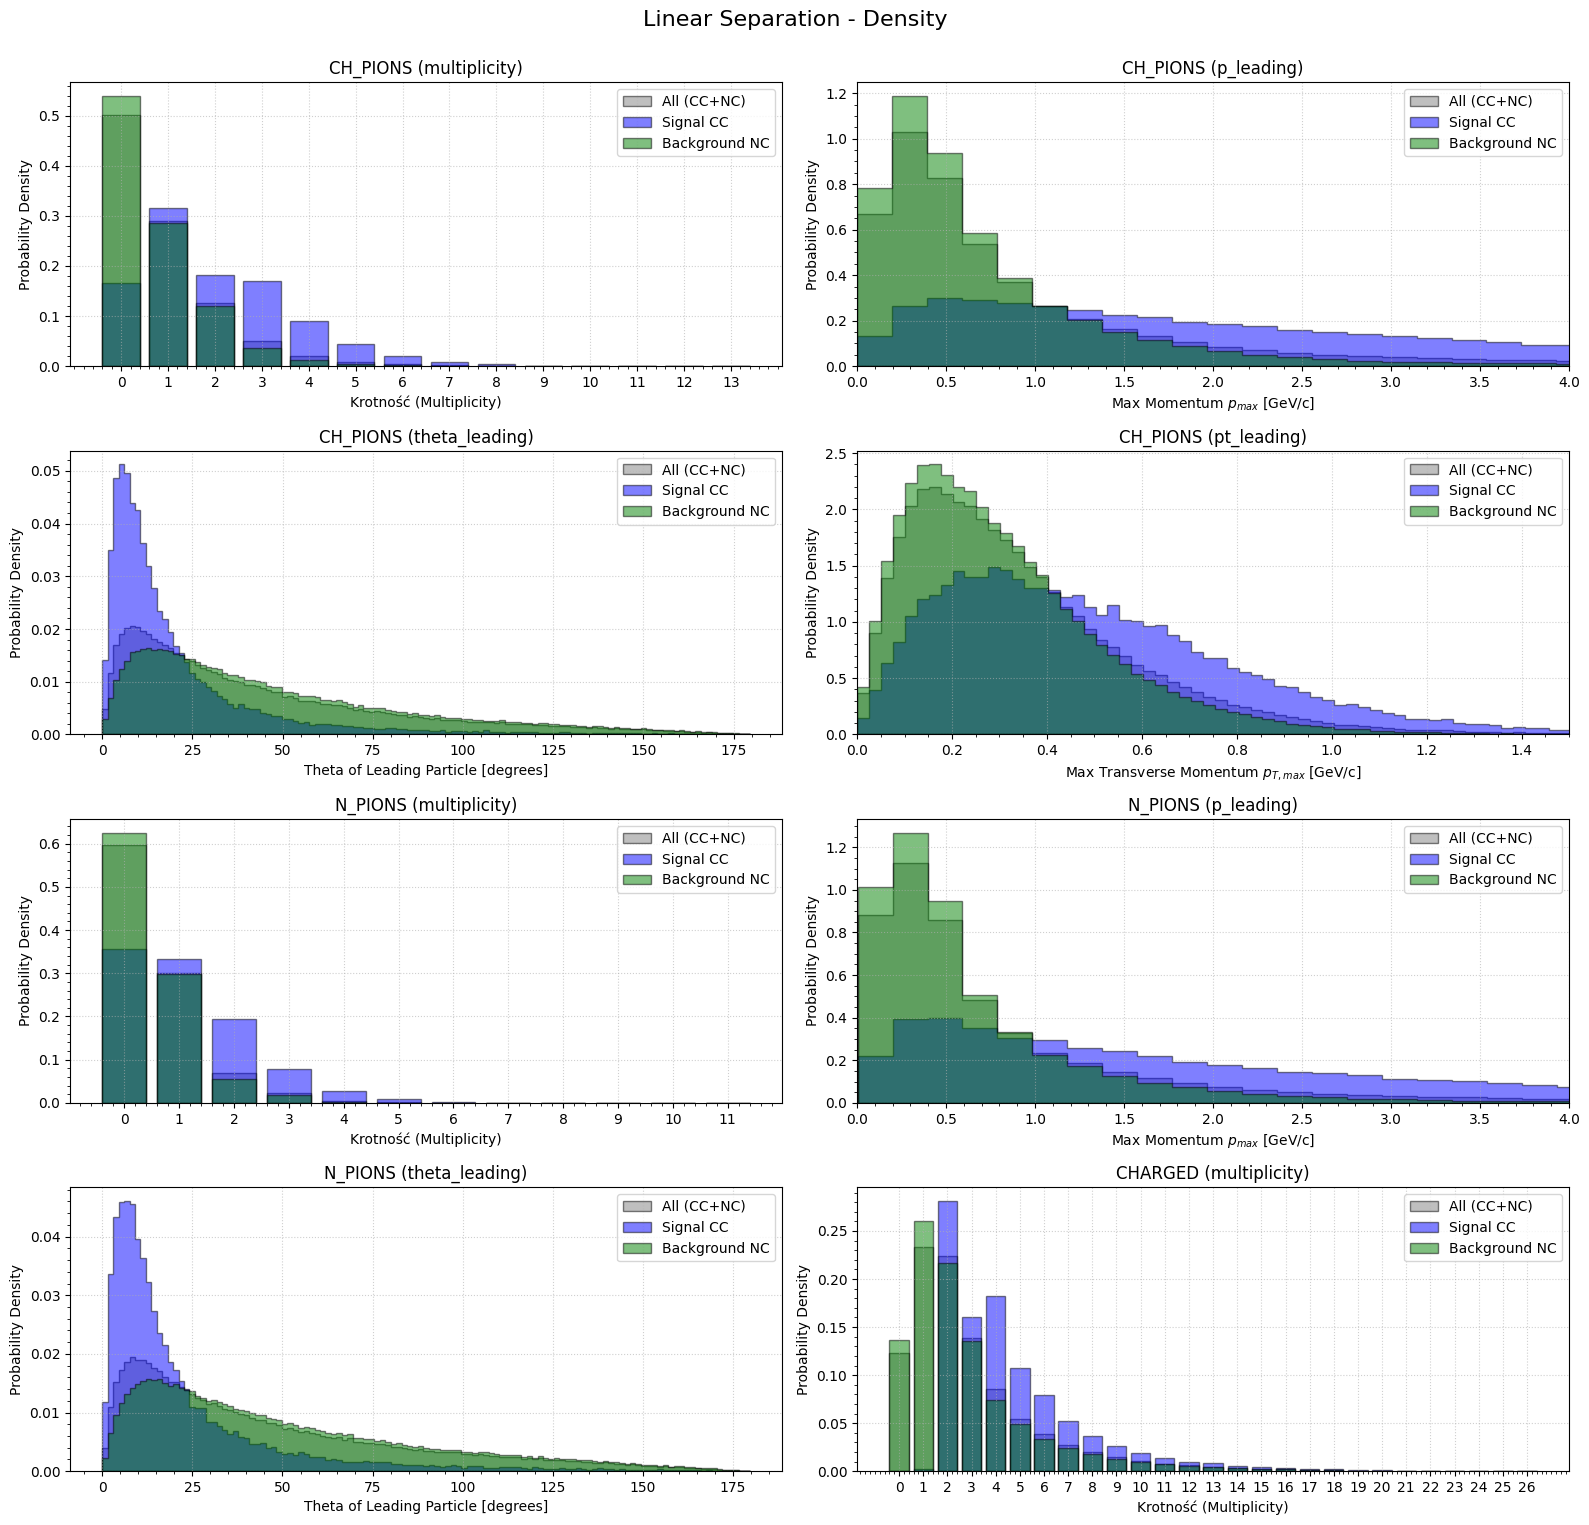

In [141]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=True)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=True)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=True)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='multiplicity', ax=axes[3, 1], density=True)

plt.suptitle("Linear Separation - Density", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


## Data Preprocess

In [11]:
#features:
# ch pions multiplicity, leading p, leading theta, leading pt - 4
# n pions multiplicity, leading p, leading theta - 3
# charged multiplicity - 1 (this has a potential for even more features, but it will in fact be not exclusively hadronic and have some overlap)

#labels:
# CC vs NC

#metadata:
# intType

In [121]:
import analysis.scripts.ml_functions as ml
importlib.reload(ml)
#take the data we analyzed above
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')
df_all = pd.read_csv(output_path_all)


batch_size=32

#the dfs need to be shuffled, later i will need to shuffle when combining samples
# df_balanced_train, df_balanced_val = ml.get_train_val_subsets(df_all, cc_per_type=30, nc_per_type=30, val_size=0.2, shuffle=True)

df_balanced_train, df_unbalanced_val = ml.get_physics_informed_split(df_all, total_train_size=2000, total_val_size=400)

train_data = ml.preProcess_data(df_balanced_train, batch_size=batch_size)
val_data = ml.preProcess_data(df_unbalanced_val, batch_size=batch_size)



 Split Complete. Overlap Check: 0 shared events.

[Validation Set Physics Profile]
CC/NC Ratio: {'NC': 0.9005102040816326, 'CC': 0.09948979591836735}
Interaction Type Ratios:
IntType
DIS    0.418367
RES    0.362245
QES    0.193878
MEC    0.025510
Name: proportion, dtype: float64
--- [INFO] Nieznane kody PDG w trybie charged: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie charged: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---


# Plotting Class Separation Hypothesis AFTER data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

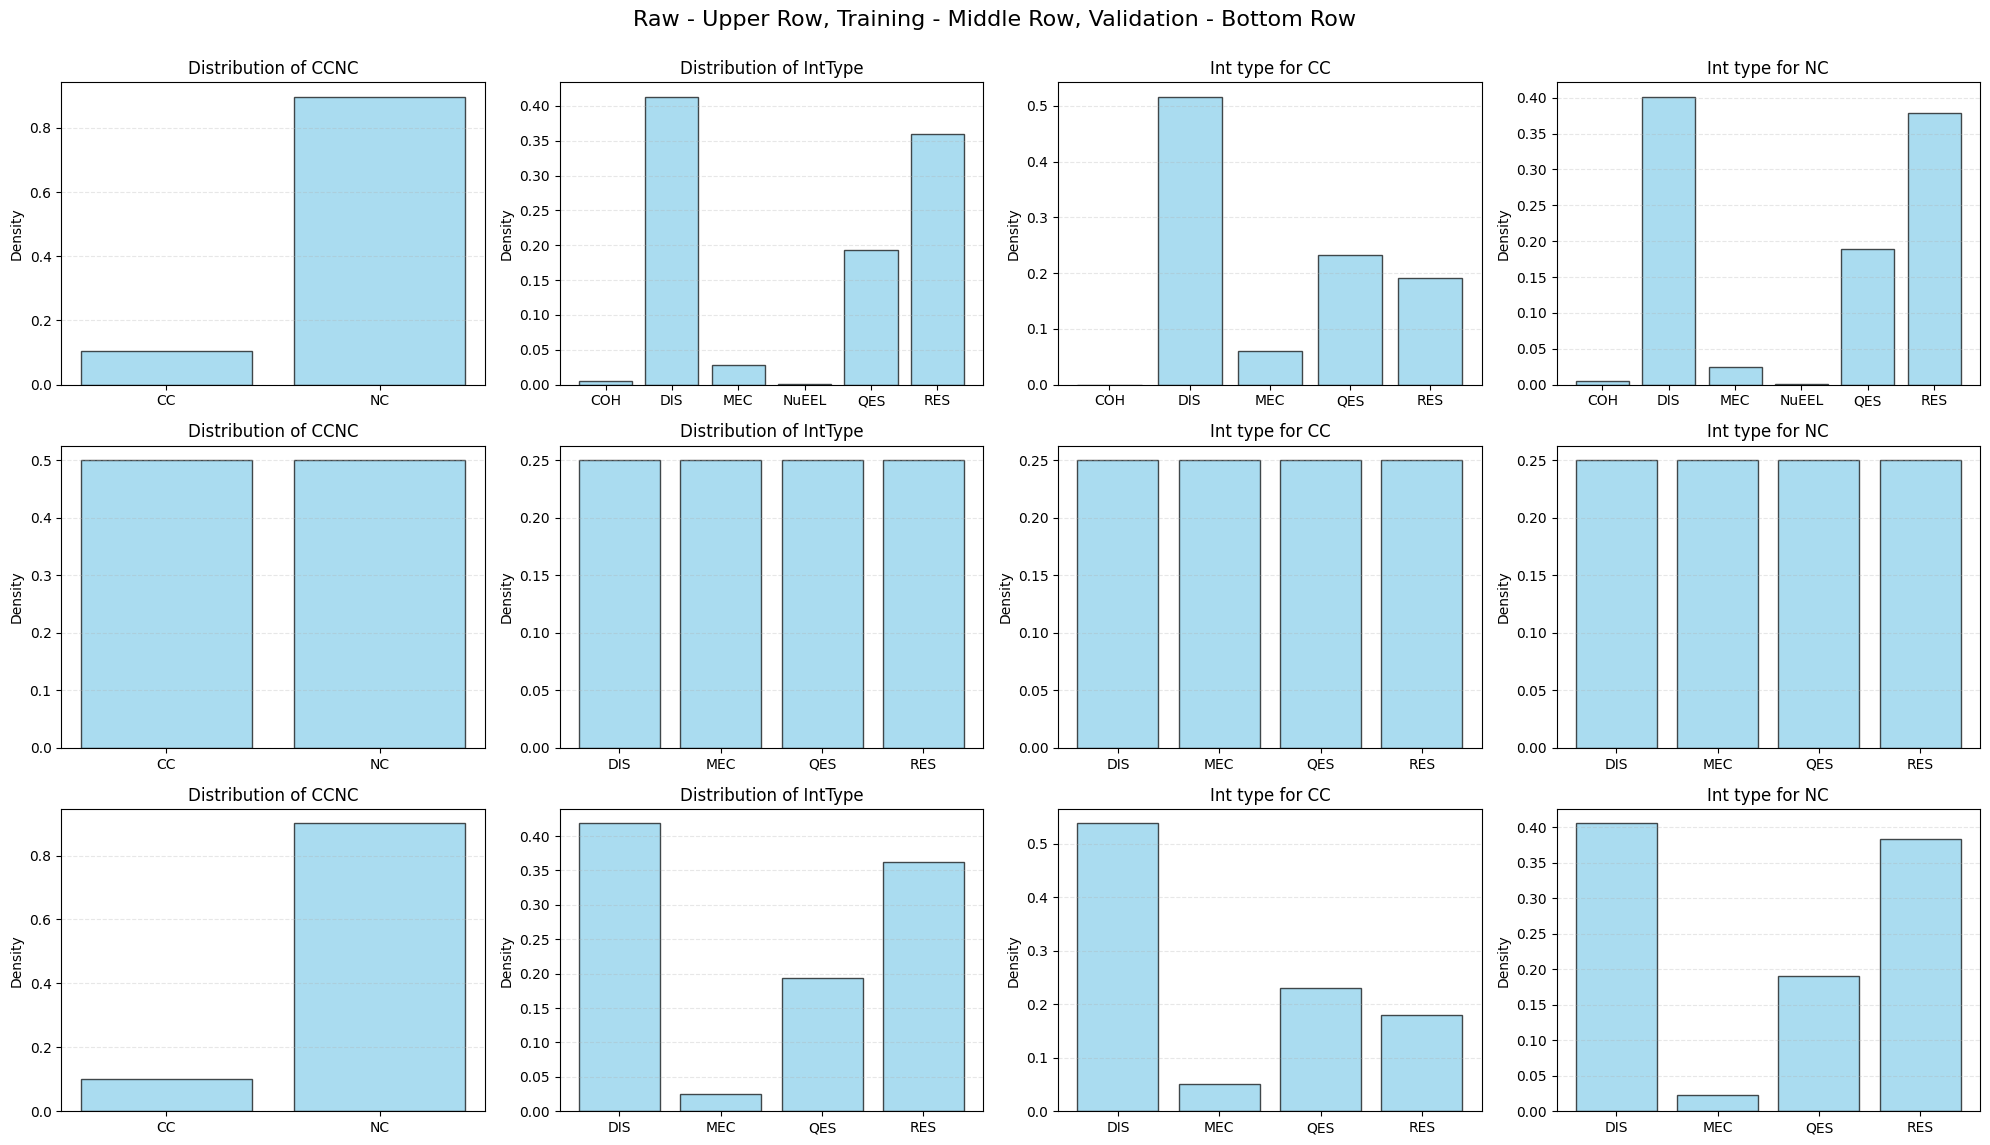

In [140]:
df_all = df_balanced_train
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

dfs_processed = [df_all, df_all_CC, df_all_NC]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

plt.suptitle("Raw - Upper Row, Training - Middle Row, Validation - Bottom Row", fontsize=16)

pf.plot_physics_results(df_legacy, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[0,1], density=True)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[0,2], density=True)
axes[0,2].set_title("Int type for CC")
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[0,3], density=True)
axes[0,3].set_title("Int type for NC")

pf.plot_physics_results(df_balanced_train, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[1,0], density=True)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[1,1], density=True)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[1,2], density=True)
axes[1,2].set_title("Int type for CC")
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[1,3], density=True)
axes[1,3].set_title("Int type for NC")

pf.plot_physics_results(df_unbalanced_val, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[2,1], density=True)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[2,2], density=True)
axes[2,2].set_title("Int type for CC")
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[2,3], density=True)
axes[2,3].set_title("Int type for NC")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


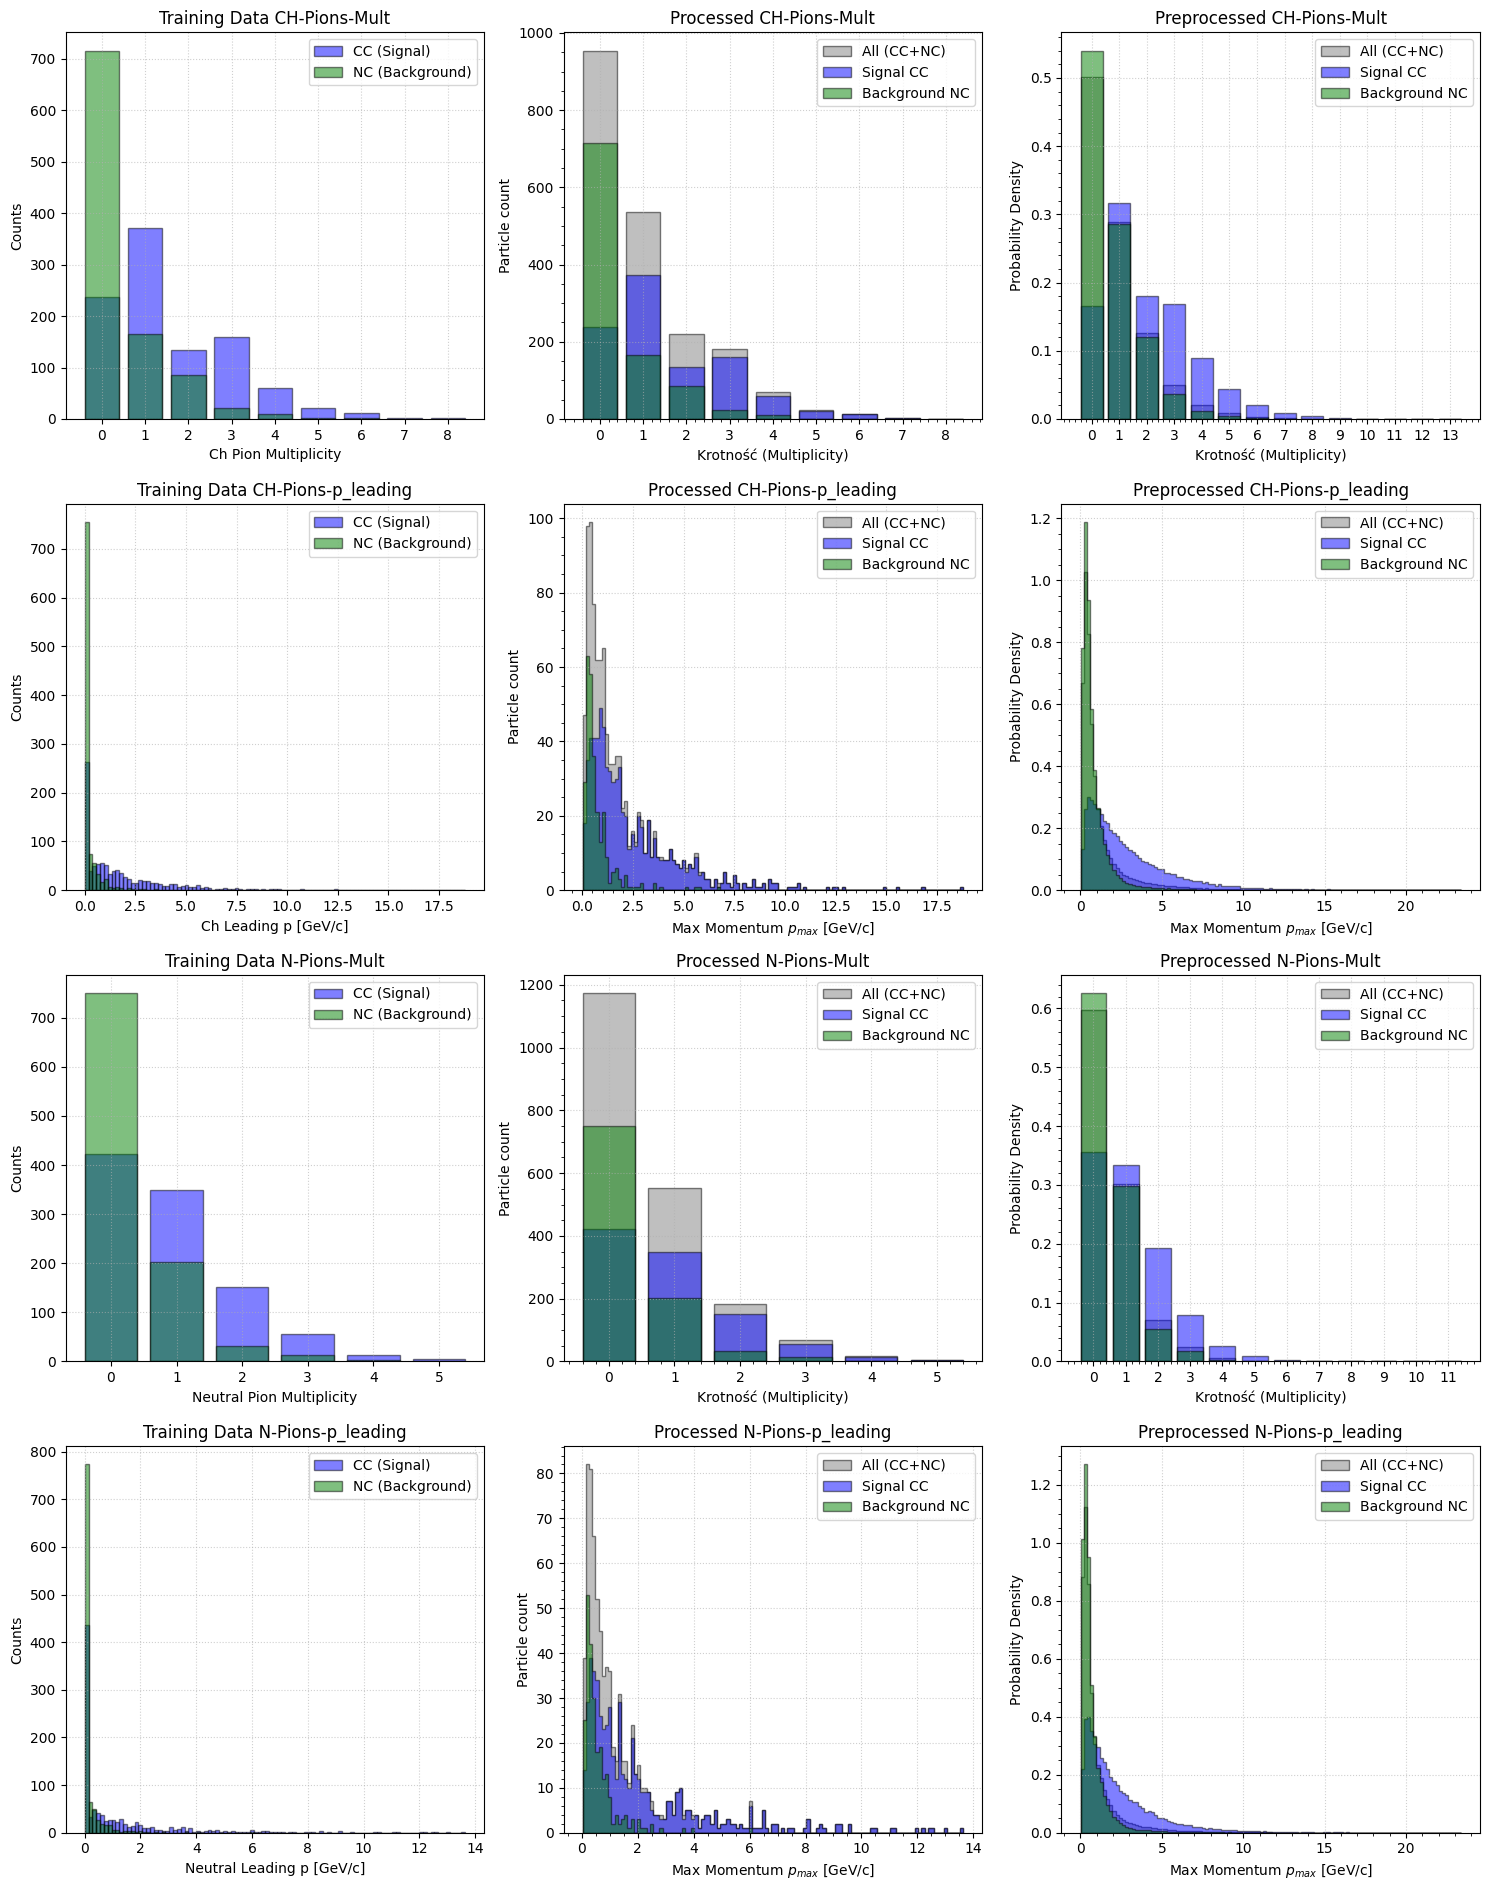

2026-04-28 15:50:15.884071: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 15:50:18.669171: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 15:50:21.800352: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 15:50:23.687521: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [139]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

# FEATURE_INDEX_MAP = {

#     0: "Ch Leading pt [GeV/c]",
#     1: "Ch Leading p [GeV/c]",
#     2: "Ch Leading Theta [deg]",
#     3: "Ch Pion Multiplicity",
#     4: "Charged Particles Multiplicity",
#     5: "Neutral Pion Multiplicity",
#     6: "Neutral Leading Theta [deg]",
#     7: "Neutral Leading p [GeV/c]"
   
# }

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(train_data, 3, ax=axes[0, 0]) 
axes[0,0].set_title("Training Data CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Processed CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 2], density=True)
axes[0,2].set_title("Preprocessed CH-Pions-Mult")    

pf.plot_feature_from_dataset(train_data, 1, ax=axes[1, 0]) 
axes[1,0].set_title("Training Data CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='p_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Processed CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[1, 2], density=True)
axes[1,2].set_title("Preprocessed CH-Pions-p_leading")    

pf.plot_feature_from_dataset(train_data, 5, ax=axes[2, 0]) # Neutral Multiplicity
axes[2,0].set_title("Training Data N-Pions-Mult") ## somethings fishy
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='multiplicity', ax=axes[2, 1], density=False)
axes[2,1].set_title("Processed N-Pions-Mult")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 2], density=True)
axes[2,2].set_title("Preprocessed N-Pions-Mult")

pf.plot_feature_from_dataset(train_data, 7, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Training Data N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Processed N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[3, 2], density=True)
axes[3,2].set_title("Preprocessed N-Pions-p_leading")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


## Model

In [125]:
#very simple 1dCNN

def getModel():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(8, 1)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        
        tf.keras.layers.Flatten(), 

        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='1dCNN_proto')
    return model

model_1dCNN = getModel()

model_1dCNN.summary()   


Model: "1dCNN_proto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_5           │ (None, 8, 1)           │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 8, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,365 (28.77 KB)

 Trainable params: 7,363 (28.76 KB)

 Non-trainable params: 2 (8.00 B)

## Training

In [126]:
import analysis.scripts.system_functions as sf
importlib.reload(sf)

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    # FP rate 
    tf.keras.metrics.Precision(name='precision'),
    # TP rate 
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

#####
nEpochs = 150
initial_learning_rate = 3E-4
#batch_size defined when creating the datasets

callbacks = [] #for testing disable checkpoints

if callbacks:
    current_run_dir = sf.get_experiment_folder("1DCNN_testing")
    checkpoint_filepath = os.path.join(current_run_dir, 'checkpoint_epoch_{epoch:02d}.weights.h5')

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, monitor='val_auc', mode='max', save_best_only=True, verbose=1)
final_model_path = os.path.join(current_run_dir, "final_model_full.keras")

# callbacks = [model_checkpoint_callback]


model_1dCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy', metrics=metrics)

In [127]:
history = model_1dCNN.fit(
    train_data,
    validation_data=val_data,
    epochs=nEpochs,
    callbacks=callbacks,
    verbose=0
)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


## Comet Exp Tracking

In [ ]:
experiment = comet_ml.start(
  api_key="8fJ8LDvz6YAWkbOxeK3ibVvsA",
  project_name="1dcnn-dune",
  workspace="grzegorz-j-drzejowski"
)


hyper_params = {
  "learning_rate": initial_learning_rate,
  "steps": nEpochs,
  "batch_size": batch_size,
}

experiment.log_parameters(hyper_params)


In [28]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : effective_pinniped_7347
COMET INFO:     url                   : https://www.comet.com/grzegorz-j-drzejowski/1dcnn-dune/2283adeaadf844c2ad9270b1a6176a1d
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch_loss [20]          : (0.6883618831634521, 0.6975240707397461)
COMET INFO:     epoch_duration [20]      : (0.033522848039865494, 1.0585827305912971)
COMET INFO:     loss [20]                : (0.6829357743263245, 0.6916994452476501)
COMET INFO:     val_loss [20]            : (0.6819986701011658, 0.751336395740509)
COMET INFO:     validate_batch_loss [20] : (0.6831826567649841, 0.7614885568618774)
COMET INFO:   Others:
COMET INFO:     train

## Save model

In [18]:
#optionally save the model explicitly (for good performing models to seperate them)
os.makedirs("models", exist_ok=True)
path = "models/1DCNN.keras"
model_1dCNN.save(path.format(epoch=nEpochs))

print(f"Model saved successfully to {path.format(epoch=nEpochs)}")

Model saved successfully to models/1DCNN.keras


## Load Model

In [19]:
#wczytanie modelu
nEpochsSaved = nEpochs

checkpoint_path = "models/1DCNN.keras"
model_load_ = tf.keras.models.load_model(checkpoint_path.format(epoch=nEpochsSaved))

model_load_.evaluate(val_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6824  


0.6819986701011658

In [ ]:
run_folder = "checkpoints/2026-04-28_1DCNN_testing(1)/" # selecting folder
epoch_to_load = 15

model_load = getModel() 
weights_path = os.path.join(run_folder, f"checkpoint_epoch_{epoch_to_load:02d}.weights.h5")

# load the weights into the architecture
if os.path.exists(weights_path):
    print(f"Loading weights from: {weights_path}")
    model_load.load_weights(weights_path)
    
    # 5. Compile is REQUIRED before evaluation to define the loss/metrics
    model_load.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3E-4),
        loss='binary_crossentropy', metrics=metrics)
    
    # 6. Evaluate
    val_loss = model_load.evaluate(val_data)
    print(f"\n--- Evaluation Results ---")
    print(f"Epoch {epoch_to_load} Validation Loss: {val_loss:.6f}")
else:
    print(f"Error: File not found at {weights_path}")

Loading weights from: checkpoints/2026-04-28_1DCNN_testing(1)/checkpoint_epoch_15.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6639  

--- Evaluation Results ---
Epoch 15 Validation Loss: 0.662442


## Evaluation

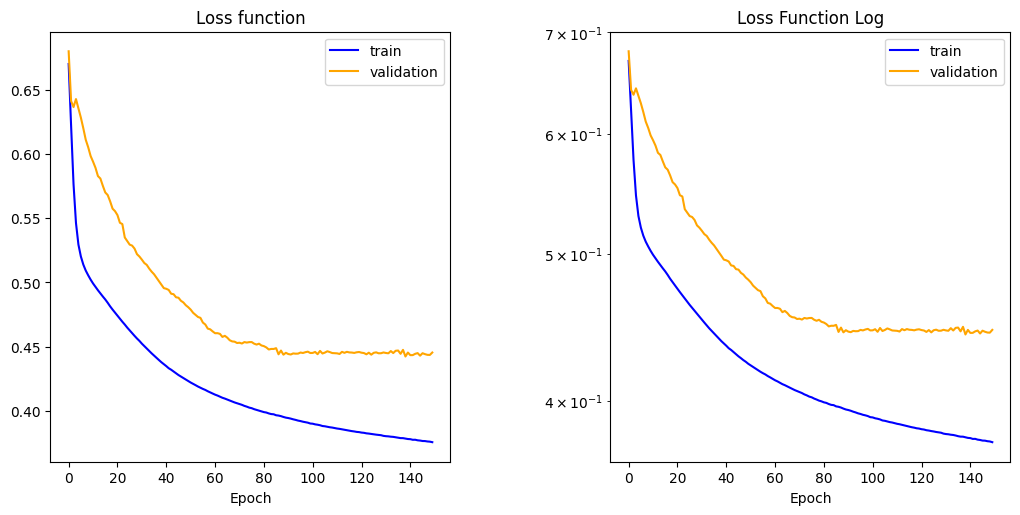

In [128]:
# eval training 

#add plotting podklas
# add CM and other metrics

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

pf.plotTrainHistory(history)

In [129]:
# 1. Get predictions and flatten them to 1D
train_preds = model_1dCNN.predict(train_data).flatten()
val_preds = model_1dCNN.predict(val_data).flatten()

df_balanced_train['Prob_is_CC'] = train_preds
df_unbalanced_val['Prob_is_CC'] = val_preds

# 3. Decision: 1 = Predicted CC, 0 = Predicted NC
df_balanced_train['NN_Decision_CC'] = (train_preds > 0.5).astype(int)
df_unbalanced_val['NN_Decision_CC'] = (val_preds > 0.5).astype(int)


 1/63 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


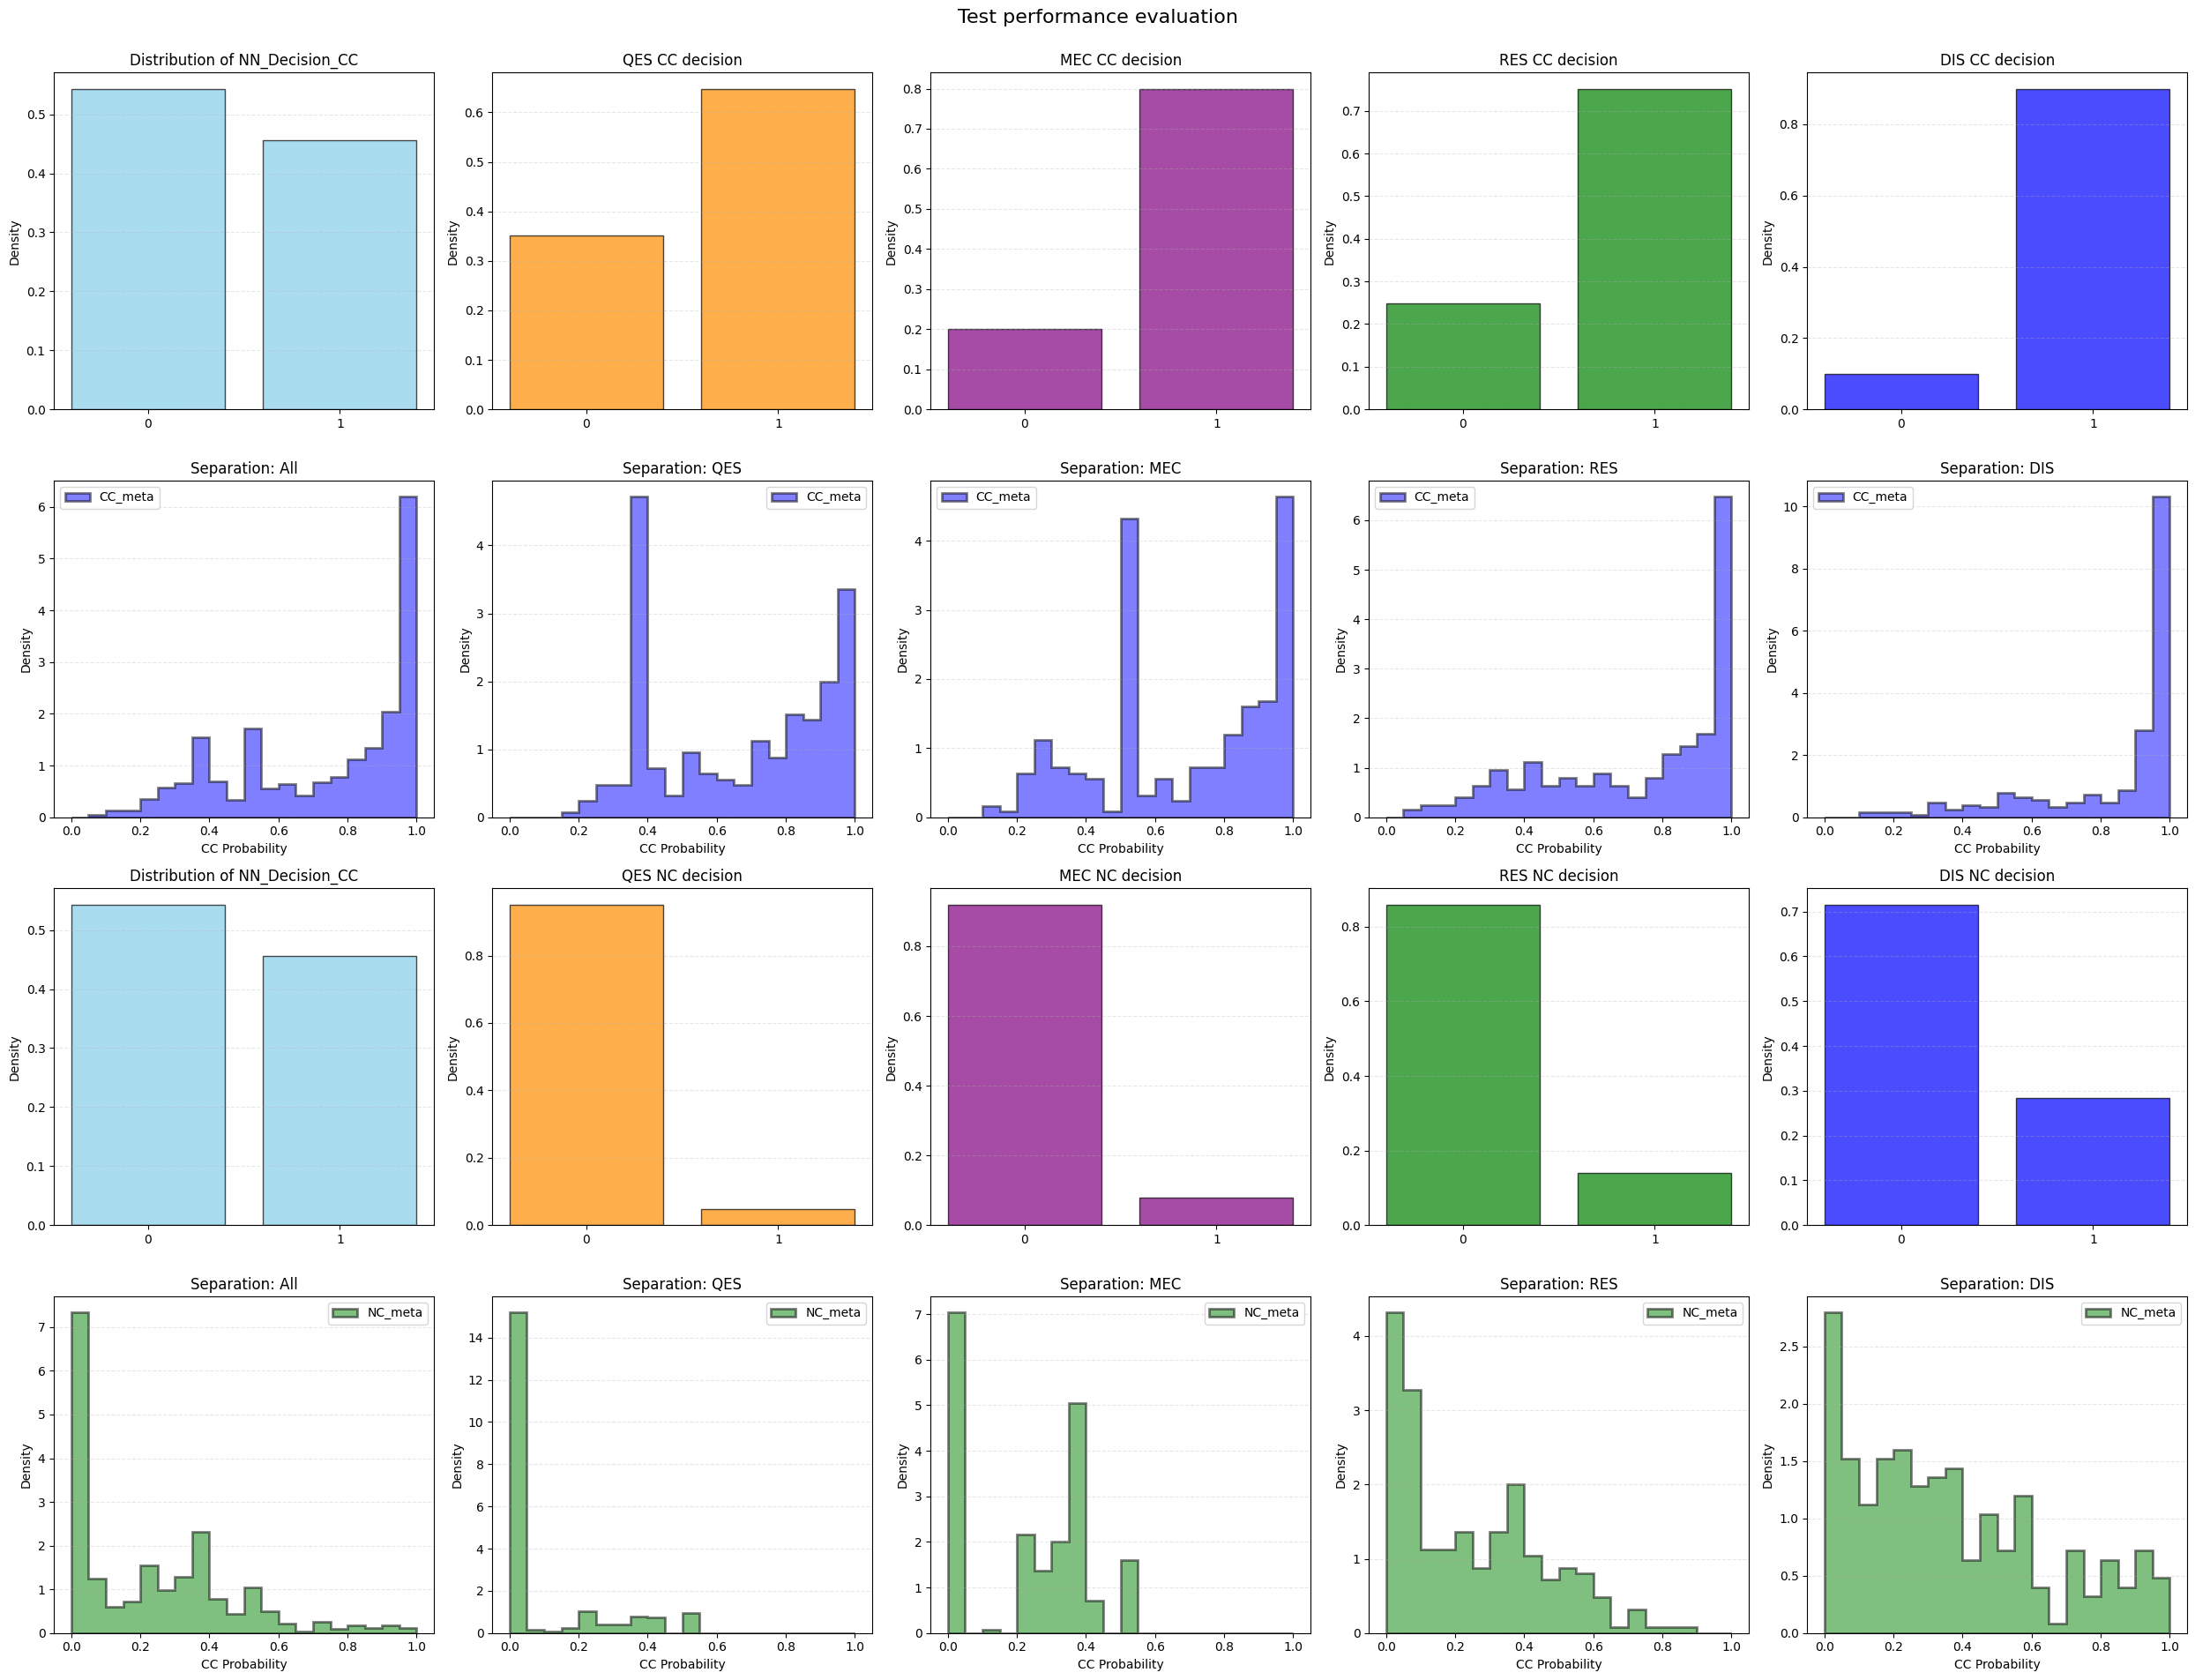

In [138]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Test performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



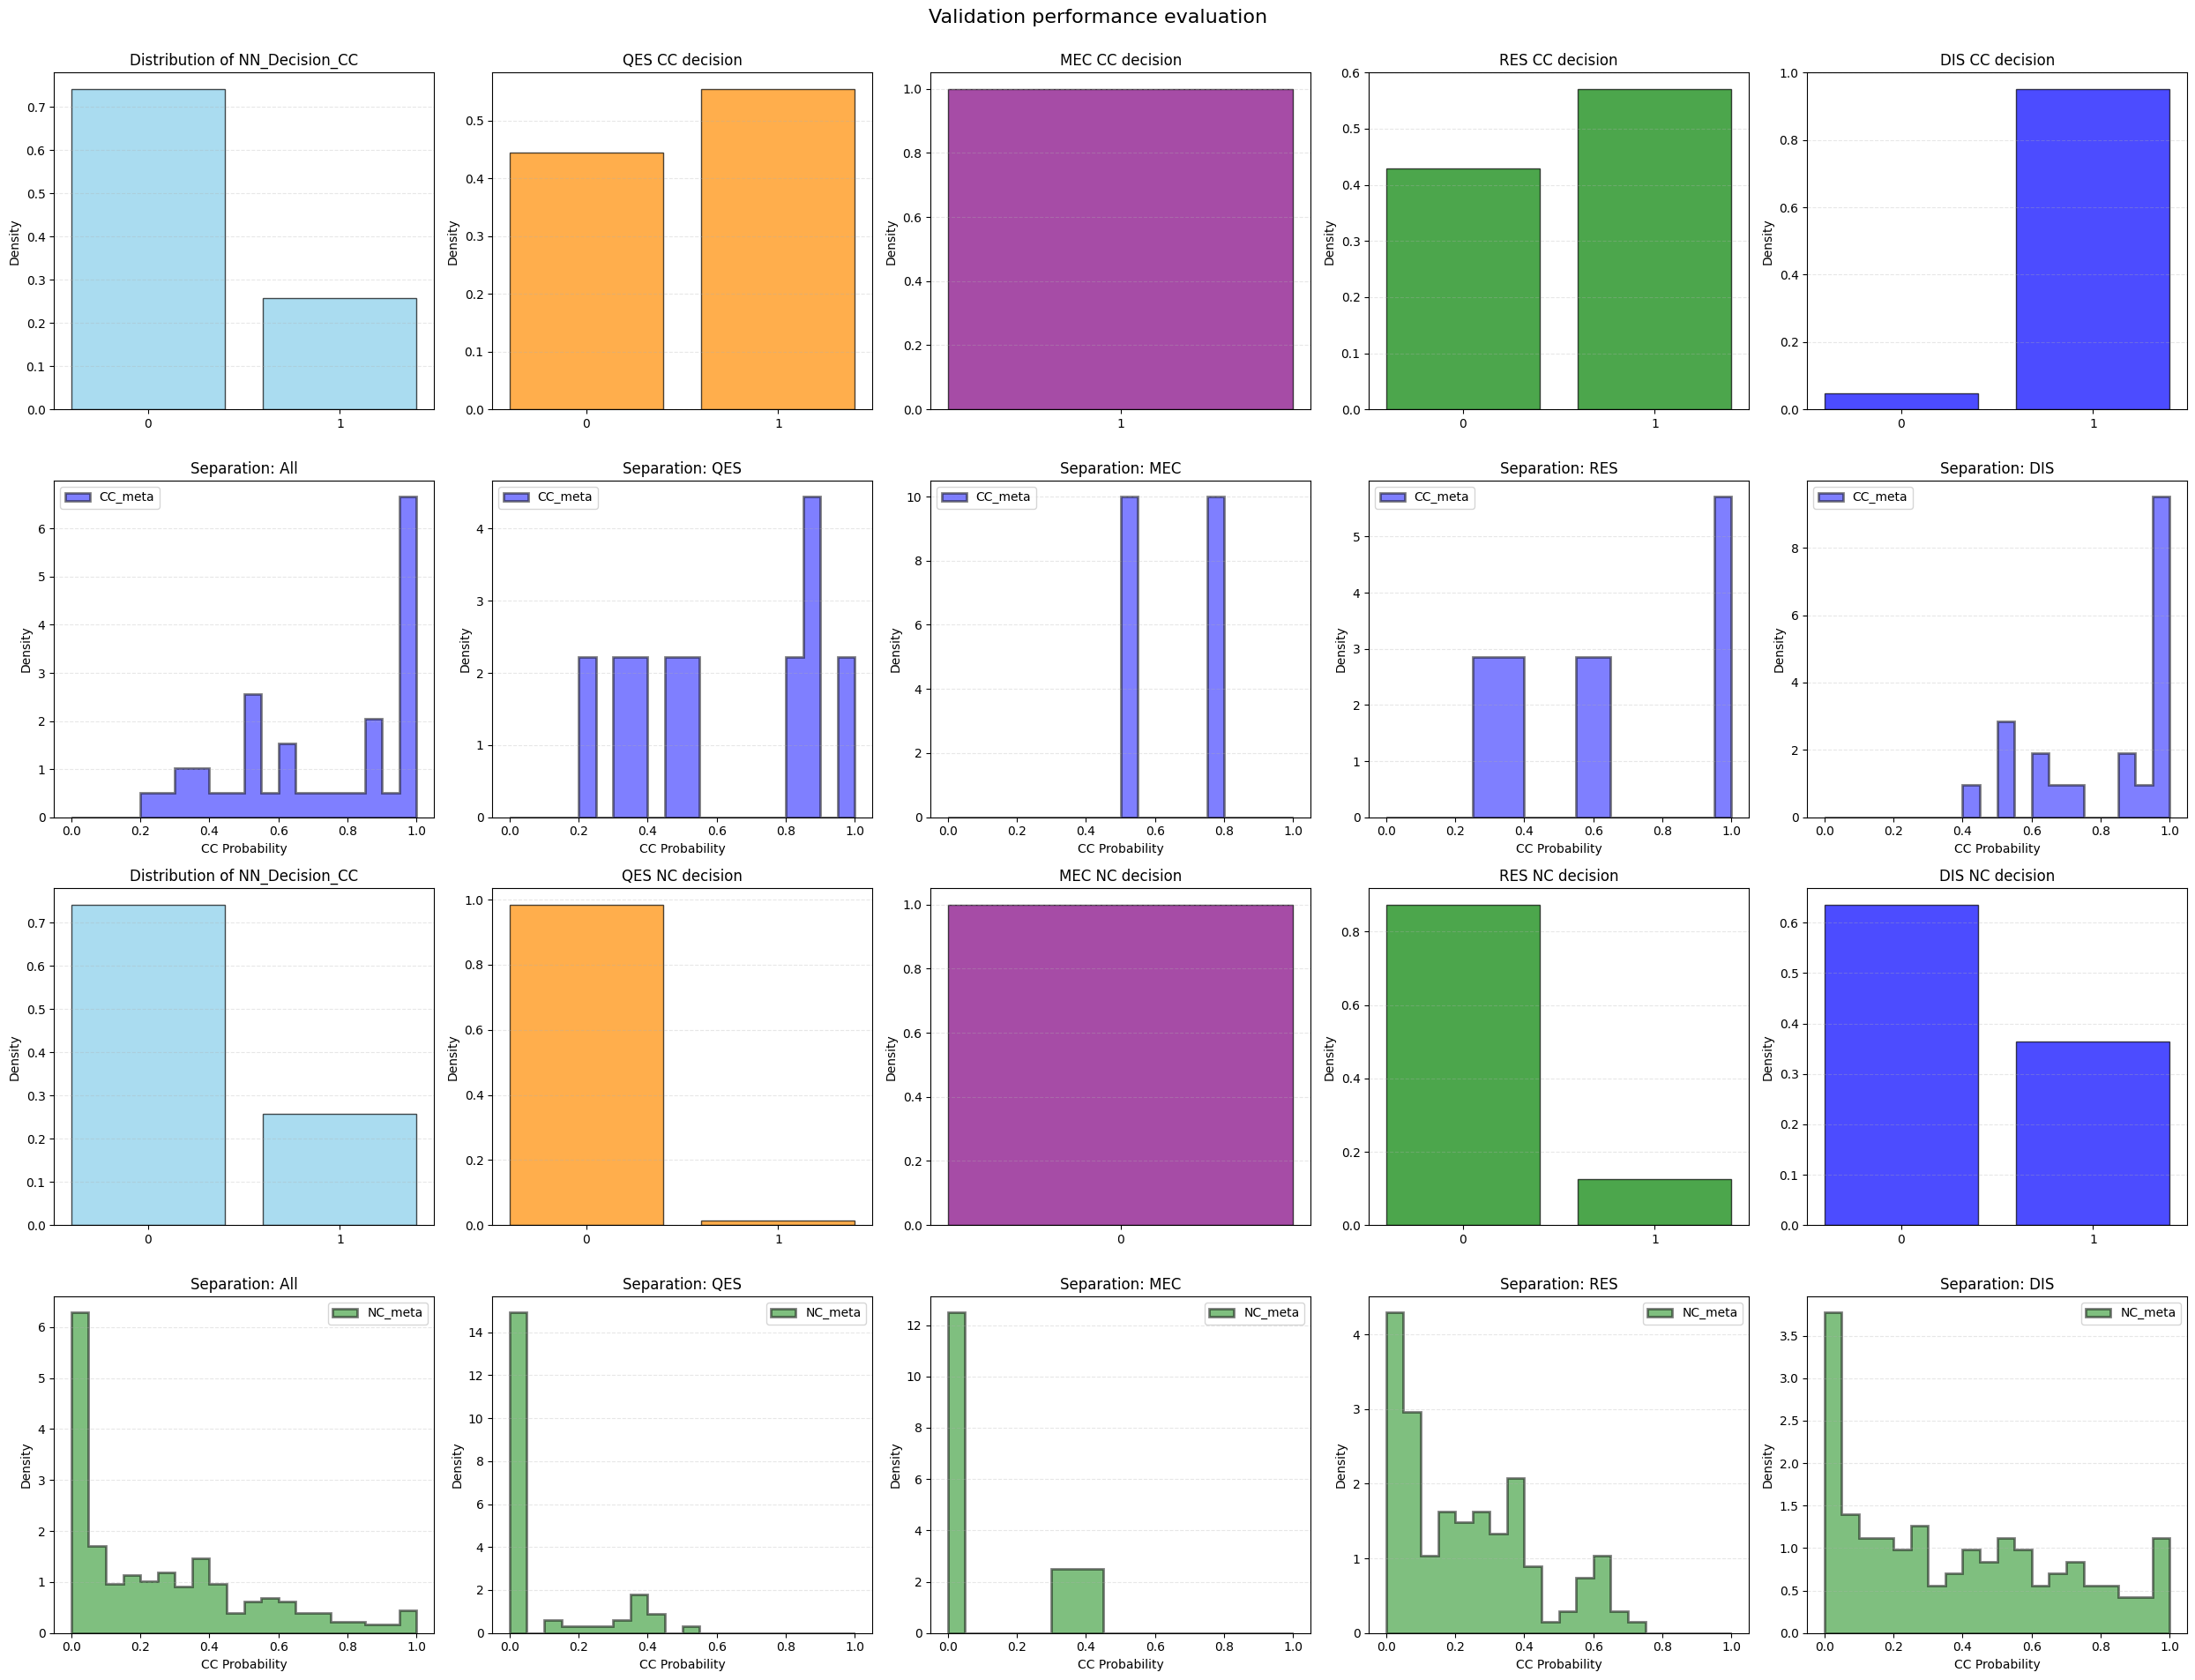

In [137]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='CC', int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='CC', int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='NC', int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='NC', int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Validation performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


1DCNN ROC AUC: 0.9098
1DCNN ROC AUC: 0.8806


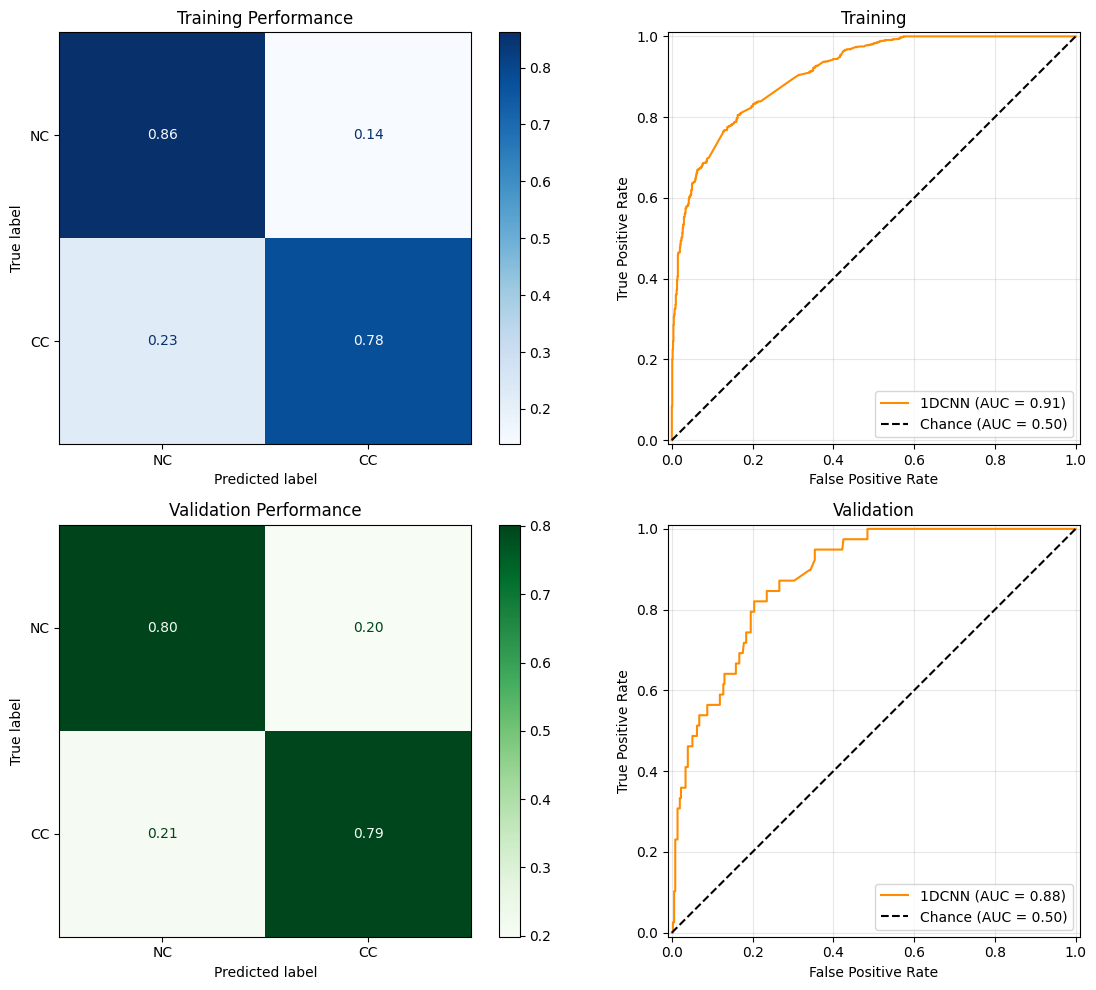

In [133]:
#CM and add metrics #plot auc
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pf.plotConfusionMatrix(df_balanced_train, title="Training Performance", ax=axes[0,0], cmap='Blues')
pf.plotROC(df_balanced_train, model_name="1DCNN", ax=axes[0,1])
axes[0,1].set_title("Training")

pf.plotConfusionMatrix(df_unbalanced_val, title="Validation Performance", ax=axes[1,0], cmap='Greens')
pf.plotROC(df_unbalanced_val, model_name="1DCNN", ax=axes[1,1])
axes[1,1].set_title("Validation")

plt.tight_layout()
plt.show()

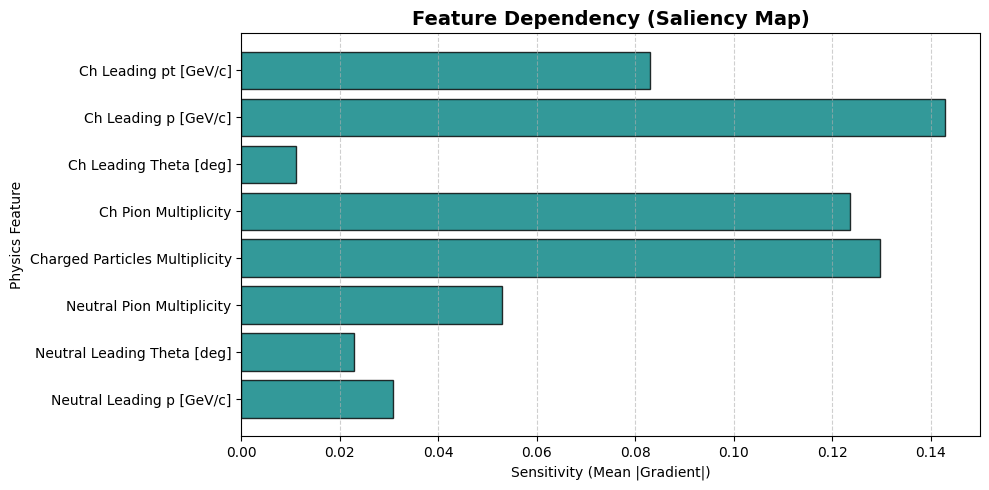

<Axes: title={'center': 'Feature Dependency (Saliency Map)'}, xlabel='Sensitivity (Mean |Gradient|)', ylabel='Physics Feature'>

In [134]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)
pf.plotFeatureImportance(model_1dCNN, val_data)